In [1]:

from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
import pandas as pd
from sklearn.model_selection import train_test_split


In [17]:
insurance_data=pd.read_csv("insurance.csv")

In [18]:

X=insurance_data.drop(columns=['charges'])
y=insurance_data["charges"]
X=pd.get_dummies(X,columns=['region'],drop_first=True,dtype=int)
X['sex']=X['sex'].map({'female':1,'male':0})
X['smoker']=X['smoker'].map({'yes':1,'no':0})

X['age_smoker']=X["age"]*X["smoker"]
X['bmi_smoker']=X["bmi"]*X["smoker"]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

MSE for alpha=0.001 : 20918648.889825605
MSE for alpha=0.1 : 20918648.889825605
MSE for alpha=1 : 20918648.889825605
MSE for alpha=2 : 20918648.889825605
MSE for alpha=5 : 20918648.889825605
MSE for alpha=10 : 20918648.889825605
MSE for alpha=20 : 20918648.889825605
MSE for alpha=30 : 20918648.889825605
MSE for alpha=40 : 20918648.889825605
MSE for alpha=50 : 20918648.889825605
MSE for alpha=100 : 20918648.889825605


<Axes: >

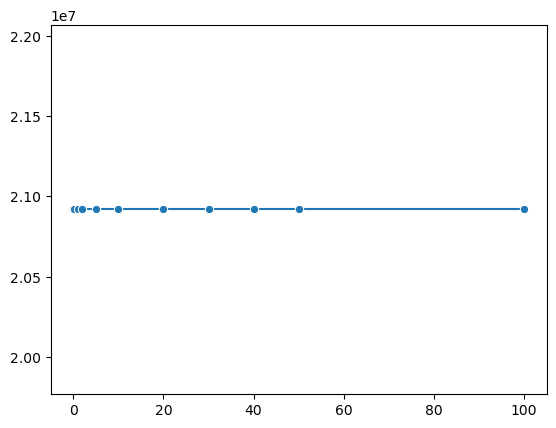

In [24]:
import seaborn as sns
alphas=[0.001,0.1,1,2,5,10,20,30,40,50,100]
mses=[]
for i in alphas:
    lasso_model = Lasso(alpha=0.5)
    lasso_model.fit(X_train,y_train)
    y_pred=lasso_model.predict(X_test)
    mse=mean_squared_error(y_test,y_pred)
    print(f"MSE for alpha={i} :",mse)
    mses.append(mse)

sns.lineplot(x=alphas,y=mses,marker="o")    

In [34]:
from sklearn.linear_model import LassoCV
a=[0.001,0.1,1,2,5,10,20,30,40,50,100]
lasso_cv_model = LassoCV(
    alphas=a,
    cv=5,
    max_iter=1000,
    random_state=42
)
lasso_cv_model.fit(X_train,y_train)
print("best alpha : ",lasso_cv_model.alpha_)

y_pred = lasso_cv_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

best alpha :  0.001
Mean Squared Error: 20922599.87103596
